# Car Selling Price Prediction

In [1]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
car = pd.read_csv('/kaggle/input/datasets/navamikhatmode/car-auction-train-csv/car_auction_train.csv')

In [3]:
car.head()

,year,make,model,trim,body,transmission,state,condition,odometer,color,interior,sellingprice
0,2012,Kia,Soul,+,Wagon,automatic,ne,4.0,53070.0,gray,black,10100
1,2012,Honda,Civic,LX,Sedan,automatic,ga,2.6,45085.0,gray,gray,10300
2,2002,Honda,Civic,EX,Sedan,automatic,ca,2.2,136649.0,black,gray,3300
3,2002,Dodge,Grand Caravan,Sport,Minivan,automatic,oh,1.9,156991.0,silver,gray,600
4,2010,Chevrolet,Silverado 1500,LT,Crew Cab,NaN,fl,3.4,42421.0,blue,black,21100


In [4]:
car.duplicated().sum()

np.int64(0)

In [5]:
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 447048 entries, 0 to 447047
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          447048 non-null  int64  
 1   make          438761 non-null  object 
 2   model         438676 non-null  object 
 3   trim          438478 non-null  object 
 4   body          436455 non-null  object 
 5   transmission  394749 non-null  object 
 6   state         447048 non-null  object 
 7   condition     437611 non-null  float64
 8   odometer      446979 non-null  float64
 9   color         426687 non-null  object 
 10  interior      432893 non-null  object 
 11  sellingprice  447048 non-null  int64  
dtypes: float64(2), int64(2), object(8)
memory usage: 40.9+ MB


In [6]:
backup = car.copy()

In [7]:
car.describe(include = 'object')

,make,model,trim,body,transmission,state,color,interior
count,438761,438676,438478,436455,394749,447048,426687,432893
unique,93,954,1902,84,2,38,19,16
top,Ford,Altima,Base,Sedan,automatic,fl,black,black
freq,75016,15459,44656,159574,380708,66371,88822,195185


## Overview PLots

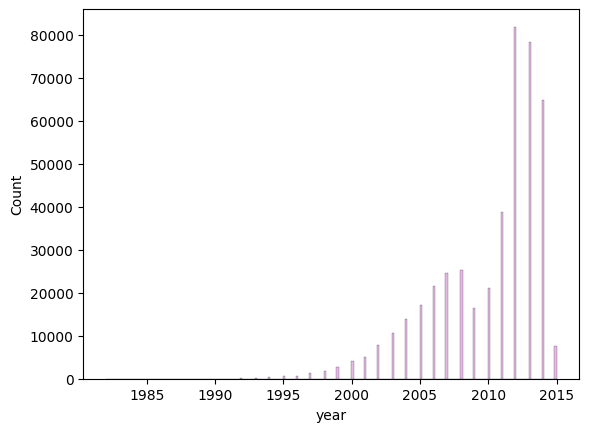

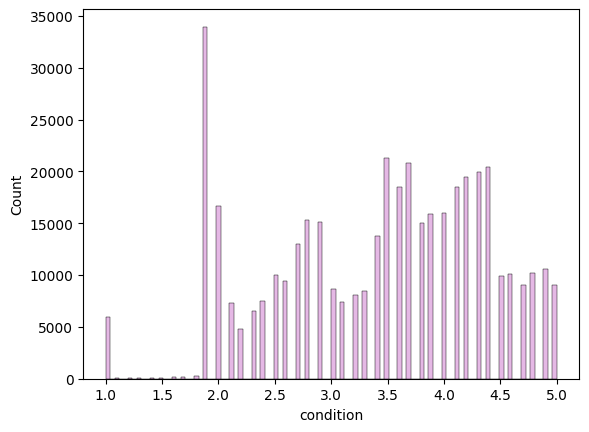

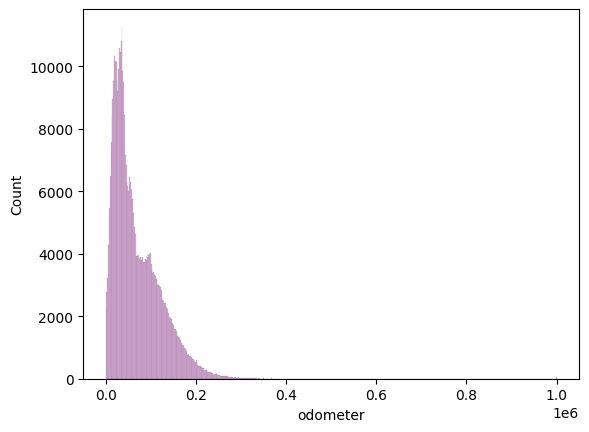

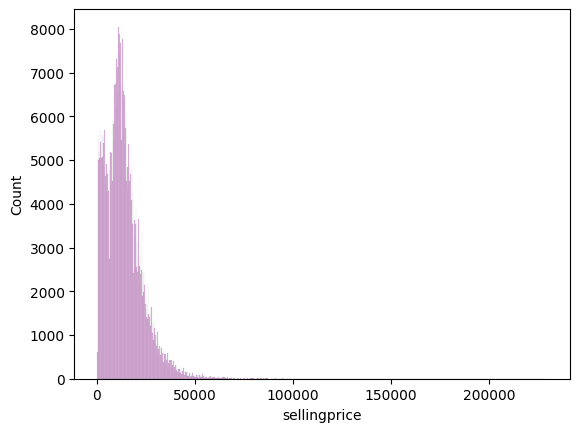

In [8]:
# Histogram plot for all the numeric data points
import warnings
warnings.filterwarnings('ignore')
for i in car.select_dtypes(include = 'number').columns:
    sns.histplot(car,x = i,color = 'plum')
    plt.show()

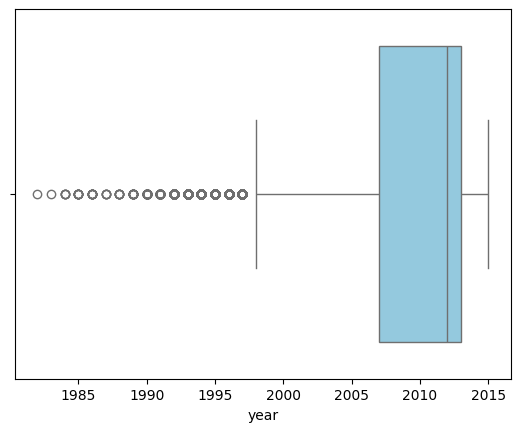

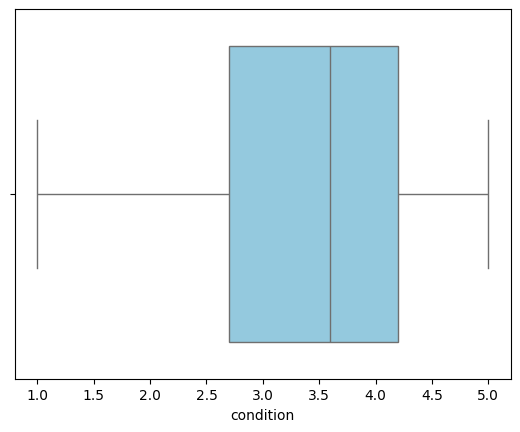

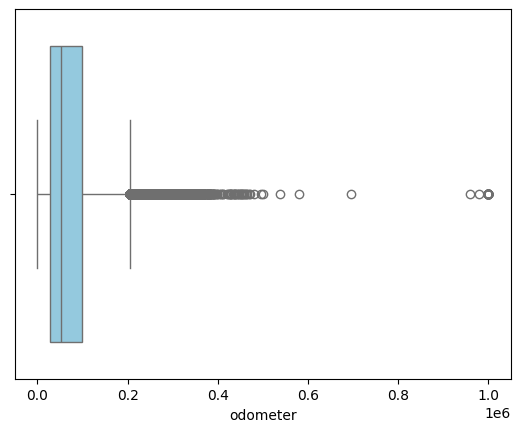

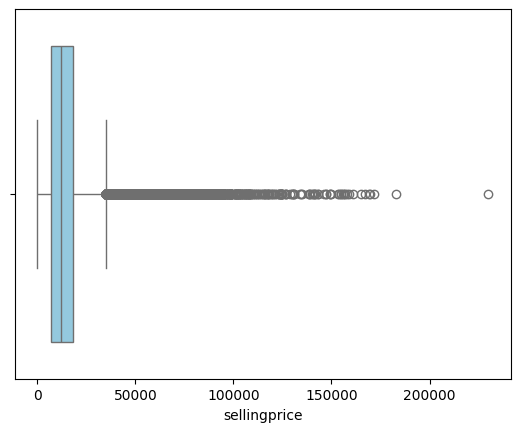

In [9]:
# Boxplot for all the numeric datapoints
for i in car.select_dtypes(include = 'number').columns:
    sns.boxplot(car,x = i,color = 'skyblue')
    plt.show()

In [10]:
# Outliers identified in
# sellingprice
# odometer
# year

In [11]:
car.columns

Index(['year', 'make', 'model', 'trim', 'body', 'transmission', 'state',
       'condition', 'odometer', 'color', 'interior', 'sellingprice'],
      dtype='object')

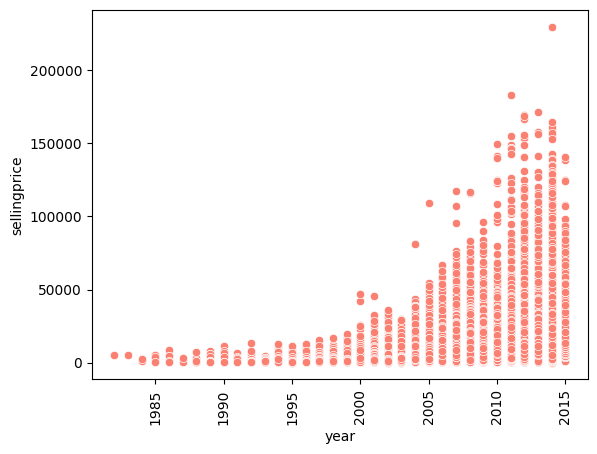

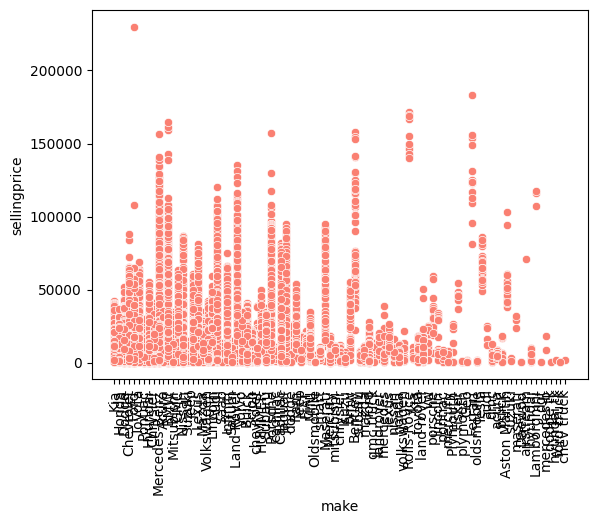

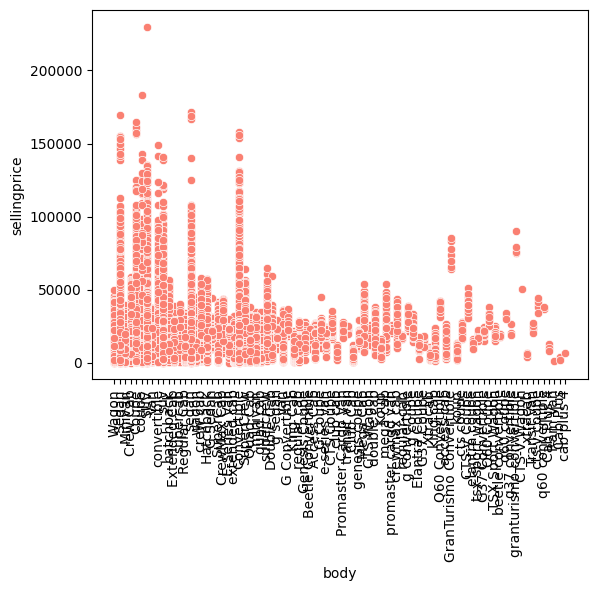

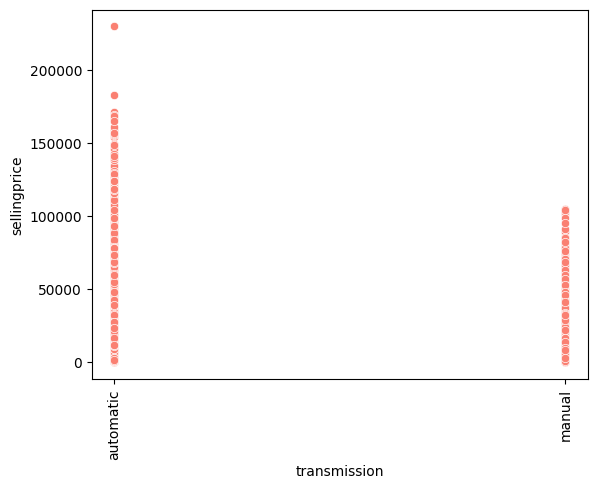

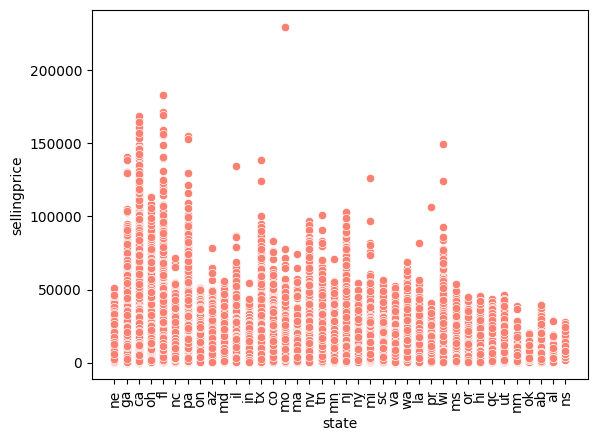

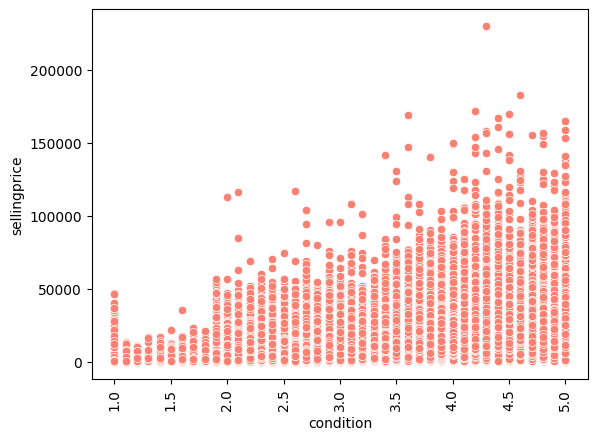

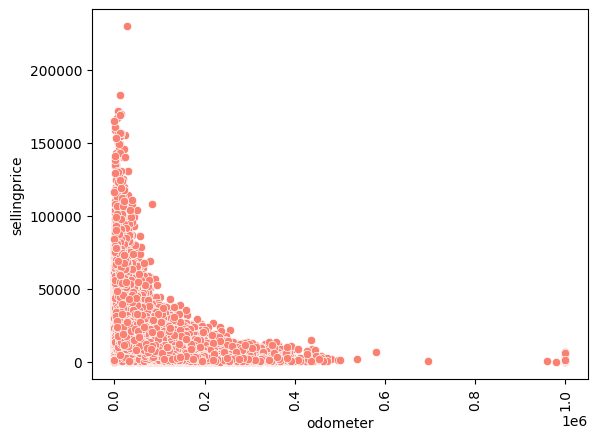

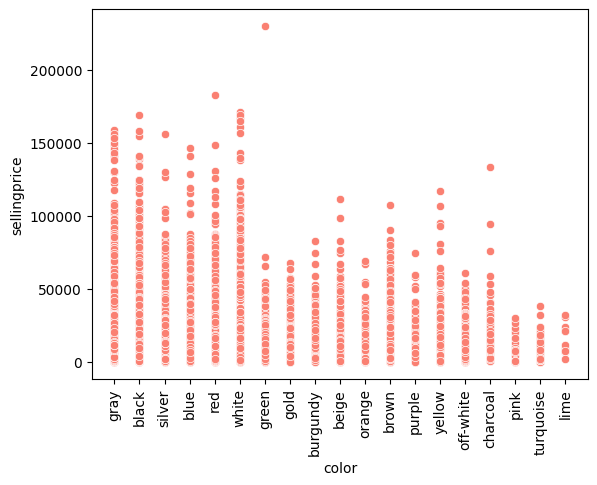

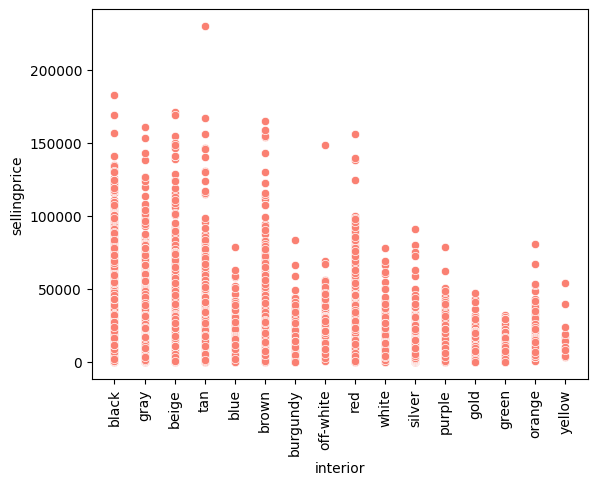

In [12]:
# Scatter plot of all the columns
for i in ['year', 'make', 'body', 'transmission', 'state',
       'condition', 'odometer', 'color', 'interior']:
    sns.scatterplot(car,x = i,y = car['sellingprice'],color = 'salmon')
    plt.xticks(rotation = 90)
    plt.show()

In [13]:
corr = car.select_dtypes(include = 'number').corr()

<Axes: >

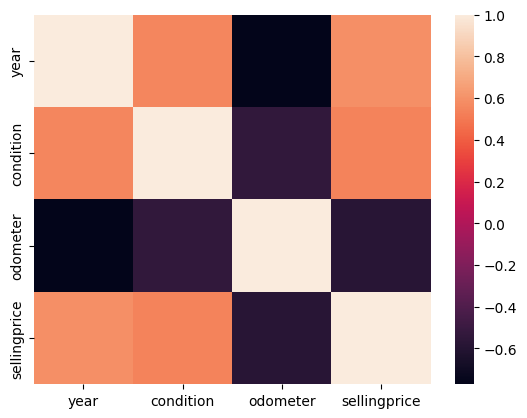

In [14]:
sns.heatmap(corr)

In [15]:
X = car[['year', 'model', 'make', 'trim', 'body', 'transmission', 'state', 'condition', 'odometer', 'color', 'interior']]
y = car['sellingprice']

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2)

## Outliers Analysis

 Insights
 Vast majority of cars have low to moderate milleage
 For the selling price a massive, dense trail of outliers extend from $50,000 to $150,000
 Right-skewed(positive) Distributions

In [17]:
# Using IQR method for odometer
# Using log transformation for selling price

Q1 = car['odometer'].quantile(0.25)
Q3 = car['odometer'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5*IQR
car = car[car['odometer'] <= upper_bound]

In [18]:
# Instead of deleting the cars that are expensive we rather use the 
# log tranformation method, this squashes the numbers in a short range 

# during predictions the value predicted will be small number ex. 10.8 
# in that case the actual price will the antilog of 10.8 (i.e np.expm1())

car['sellingprice'] = np.log1p(car['sellingprice'])


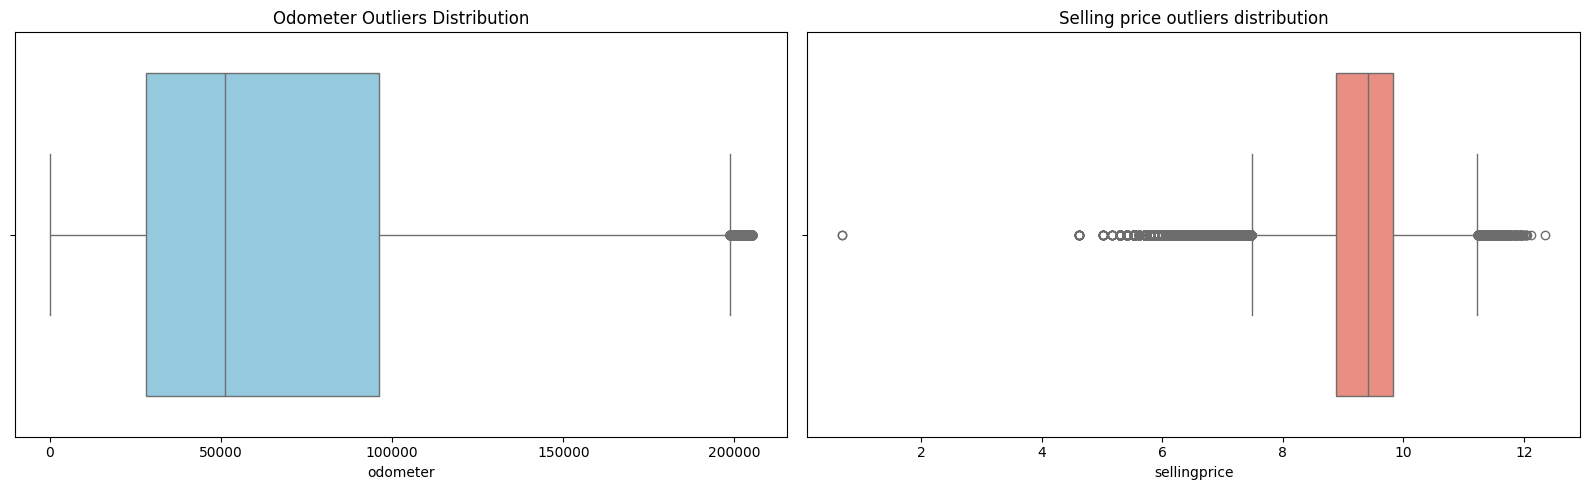

In [19]:
fig, axes = plt.subplots(1,2, figsize = (16,5))

# Odometer Boxplot
sns.boxplot(ax = axes[0], x = car['odometer'], color = 'skyblue')
axes[0].set_title('Odometer Outliers Distribution')

# Selling price boxplot
sns.boxplot(ax = axes[1], x = car['sellingprice'], color = 'salmon')
axes[1].set_title('Selling price outliers distribution')

plt.tight_layout()
plt.show()

## Data Preprocessing

In [20]:
#Checking the total missing values per column
missing_count = car.isnull().sum()
missing_percent = (missing_count/len(car))*100

In [21]:
print(missing_count)

year                0
make             7749
model            7834
trim             8018
body             9872
transmission    51045
state               0
condition        8788
odometer            0
color           20253
interior        13482
sellingprice        0
dtype: int64


In [22]:
print(missing_percent)

year             0.000000
make             1.766226
model            1.785600
trim             1.827539
body             2.250121
transmission    11.634665
state            0.000000
condition        2.003045
odometer         0.000000
color            4.616258
interior         3.072947
sellingprice     0.000000
dtype: float64


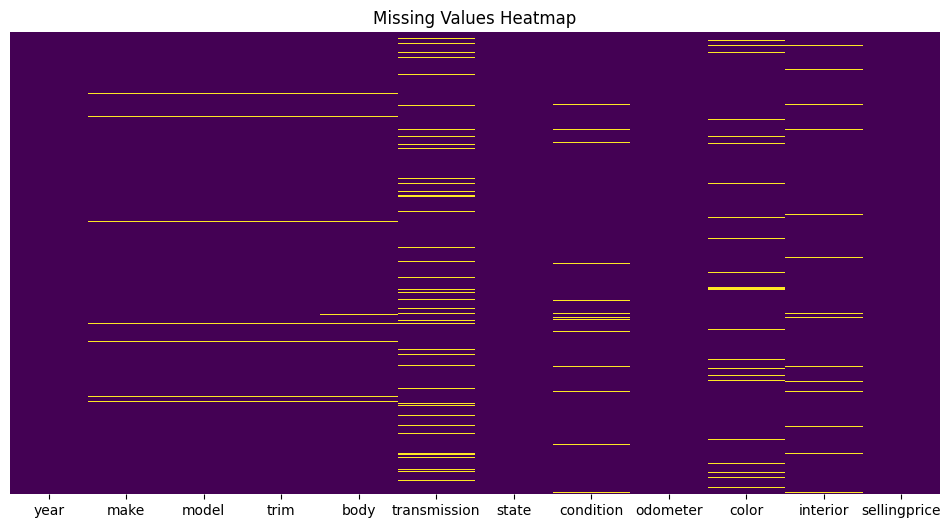

In [23]:
# To analyse the missing data visually, plotted a heatmap
plt.figure(figsize = (12,6))
sns.heatmap(car.isnull(), yticklabels = False, cbar = False, cmap = 'viridis')
plt.title('Missing Values Heatmap')
plt.show()
# Yellow lines: Missing values in the dataset

Observations : 
Transmission -> 11% of data lacks transmission, hence can't be dropped directly

Make, model, trim, body -> When a vehicles make is missing its model and trim goes missing too

Year, state, odometer, selling price -> 100% data available

Condition, color, interior -> Minor omissions


In [24]:
# Missing percent (odometer) = 0.015%, safer to drop those 69 rows 
car = car.dropna(subset = ['odometer'])
    
# Missing percent (condition) ~ 2.1% a bit higher -> used mode imputation   
car['condition'] = car['condition'].fillna(car['condition'].median())

# Handled Transimission, trim & body missing data using Grouped mode imputation
car['transmission'] = car.groupby(['make', 'model'])['transmission'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else'automatic'))

car['trim'] = car.groupby(['make', 'model'])['trim'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Base'))

car['body'] = car.groupby(['make','model'])['body'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'unkown'))

In [25]:
car.info()

<class 'pandas.core.frame.DataFrame'>
Index: 438732 entries, 0 to 447047
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          438732 non-null  int64  
 1   make          430983 non-null  object 
 2   model         430898 non-null  object 
 3   trim          430898 non-null  object 
 4   body          430898 non-null  object 
 5   transmission  430898 non-null  object 
 6   state         438732 non-null  object 
 7   condition     438732 non-null  float64
 8   odometer      438732 non-null  float64
 9   color         418479 non-null  object 
 10  interior      425250 non-null  object 
 11  sellingprice  438732 non-null  float64
dtypes: float64(3), int64(1), object(8)
memory usage: 43.5+ MB


In [26]:
missing_percent2 = ((car.isnull().sum())/len(car))*100
print(missing_percent2)

year            0.000000
make            1.766226
model           1.785600
trim            1.785600
body            1.785600
transmission    1.785600
state           0.000000
condition       0.000000
odometer        0.000000
color           4.616258
interior        3.072947
sellingprice    0.000000
dtype: float64


In [27]:
# As make and model are core features for predicting its selling price (also correlated)
# Imputing them when both are missing would introduce a lot of noise in the data
# As their missing percent is ~ 1.85% (less) its safe to drop their rows

car = car.dropna(subset = ['make', 'model'])

In [28]:
# As using any imputation method for color and interior feature would
# create noise in the data -> simply address the missing values to unknown

car['color'] = car['color'].fillna('unkown')
car['interior'] = car['interior'].fillna('unkown')

In [29]:
missing_percent3 = ((car.isnull().sum())/len(car))*100
print(missing_percent3)

year            0.0
make            0.0
model           0.0
trim            0.0
body            0.0
transmission    0.0
state           0.0
condition       0.0
odometer        0.0
color           0.0
interior        0.0
sellingprice    0.0
dtype: float64


## Feature Engineering

In [30]:
# Year column is less predictive, creating age
car['age'] = 2026 - car['year']

# Target Encoding for the high cardinality columns -> Represents historical
# average log selling price

car['mileage_peryear'] = car['odometer']/car['age']

In [31]:
car.info()

<class 'pandas.core.frame.DataFrame'>
Index: 430898 entries, 0 to 447047
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   year             430898 non-null  int64  
 1   make             430898 non-null  object 
 2   model            430898 non-null  object 
 3   trim             430898 non-null  object 
 4   body             430898 non-null  object 
 5   transmission     430898 non-null  object 
 6   state            430898 non-null  object 
 7   condition        430898 non-null  float64
 8   odometer         430898 non-null  float64
 9   color            430898 non-null  object 
 10  interior         430898 non-null  object 
 11  sellingprice     430898 non-null  float64
 12  age              430898 non-null  int64  
 13  mileage_peryear  430898 non-null  float64
dtypes: float64(4), int64(2), object(8)
memory usage: 49.3+ MB


In [32]:
import sklearn 
from sklearn.model_selection import train_test_split

In [33]:
X = car[['year', 'make','model','transmission','trim','interior','color','age','mileage_peryear','odometer','state','body','condition']]
y = car['sellingprice']

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2)

In [35]:
X_train.head()

,year,make,model,transmission,trim,interior,color,age,mileage_peryear,odometer,state,body,condition
362950,2007,Mercedes-Benz,S-Class,automatic,S550 4MATIC,brown,black,19,4303.000000,81757.0,nj,Sedan,3.6
61565,2006,BMW,X3,automatic,3.0i,beige,black,20,5026.600000,100532.0,nv,SUV,3.6
68531,2003,Acura,MDX,automatic,Touring,black,black,23,7532.521739,173248.0,ca,SUV,2.7
323888,2010,Chevrolet,Camaro,automatic,2LT,black,black,16,626.750000,10028.0,mn,coupe,4.8
275087,2006,BMW,3 Series,automatic,325Ci,beige,blue,20,2270.850000,45417.0,fl,convertible,4.4


In [36]:
np.expm1(y).head()

0    10100.0
1    10300.0
2     3300.0
3      600.0
4    21100.0
Name: sellingprice, dtype: float64

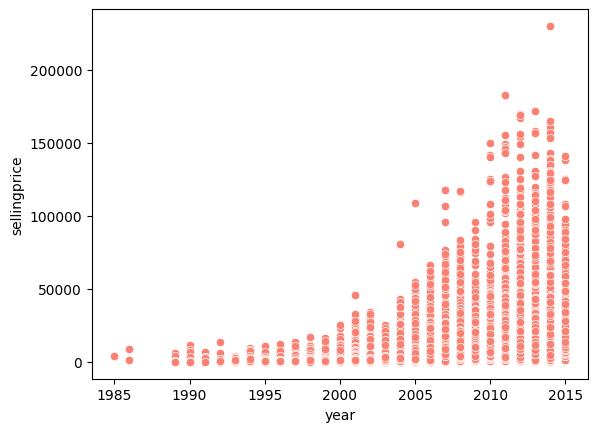

In [37]:
sns.scatterplot(X,x = X['year'],y = np.expm1(y), color = 'salmon')
plt.show()

<Axes: xlabel='age', ylabel='sellingprice'>

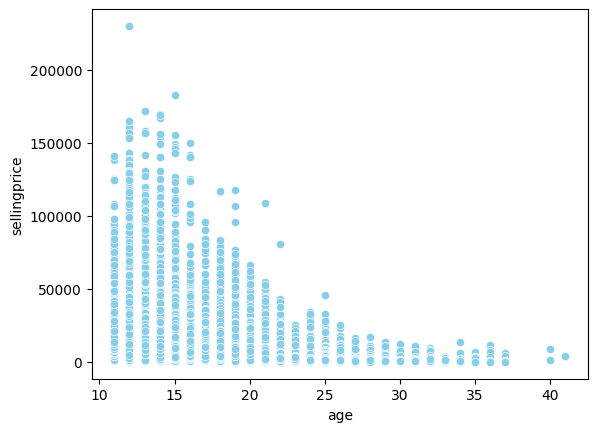

In [38]:
sns.scatterplot(X, x = X['age'],y = np.expm1(y),color = 'skyblue')

<Axes: xlabel='condition', ylabel='sellingprice'>

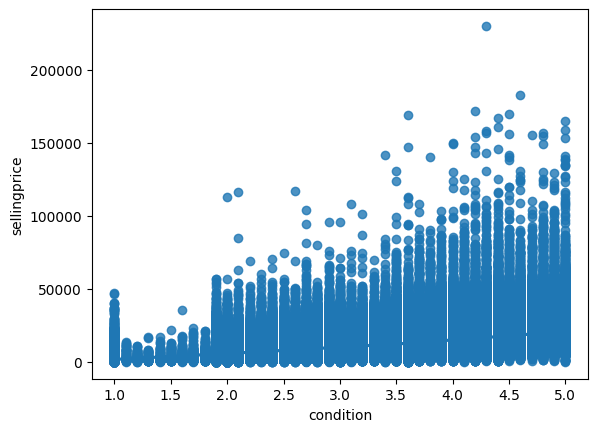

In [39]:
# Non linearity condition rating thresholds
sns.regplot(X, x = X['condition'], y = np.expm1(y),lowess = True)

# EDA

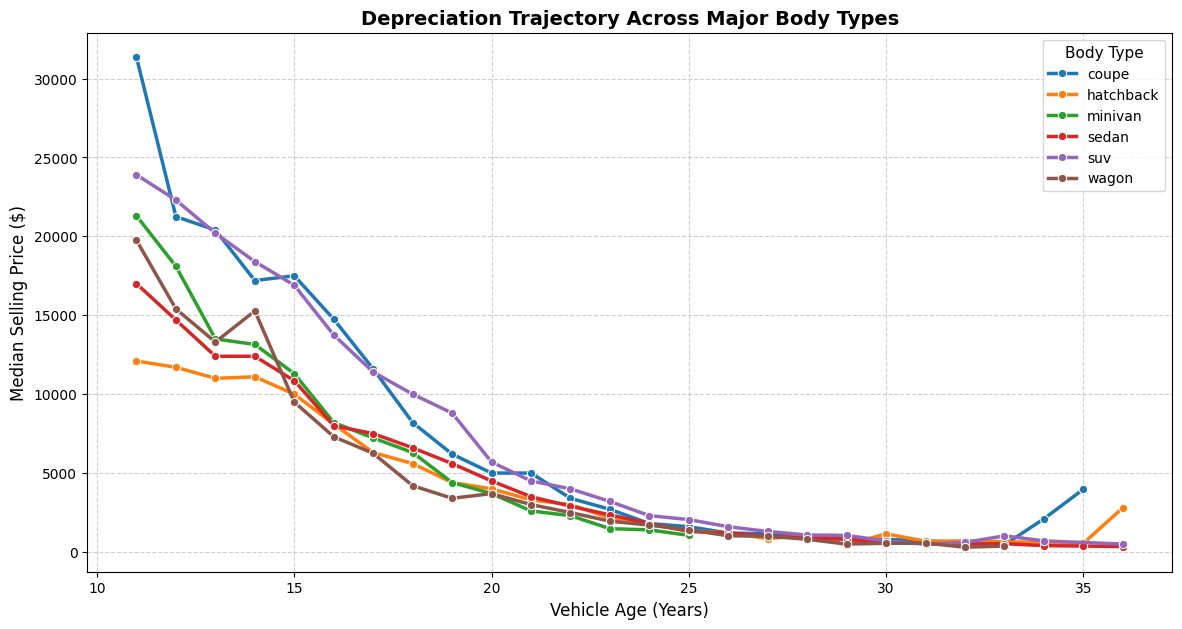

In [40]:
# STEP.1 Analyze Depreciation Dynamics across Body Types

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. Combine training features and target for analysis
train_df = X_train.copy()
train_df['sellingprice_actual'] = np.expm1(y_train)

# 2. Clean 'body' column to fix case inconsistencies (e.g., 'sedan' vs 'Sedan')
train_df['body'] = train_df['body'].str.lower().str.strip()

# 3. Filter for top 6 body types to keep the line plot clean and interpretable
top_bodies = train_df['body'].value_counts().nlargest(6).index
df_depreciation = train_df[train_df['body'].isin(top_bodies)]

# 4. Calculate the median selling price for each age and body type combination
deprec_summary = df_depreciation.groupby(['age', 'body'])['sellingprice_actual'].median().reset_index()

# 5. Plot the interaction curves
plt.figure(figsize=(14, 7))
sns.lineplot(data=deprec_summary, x='age', y='sellingprice_actual', hue='body', marker='o', linewidth=2.5)
plt.title('Depreciation Trajectory Across Major Body Types', fontsize=14, fontweight='bold')
plt.xlabel('Vehicle Age (Years)', fontsize=12)
plt.ylabel('Median Selling Price ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Body Type', title_fontsize='11', loc='upper right')
plt.show()

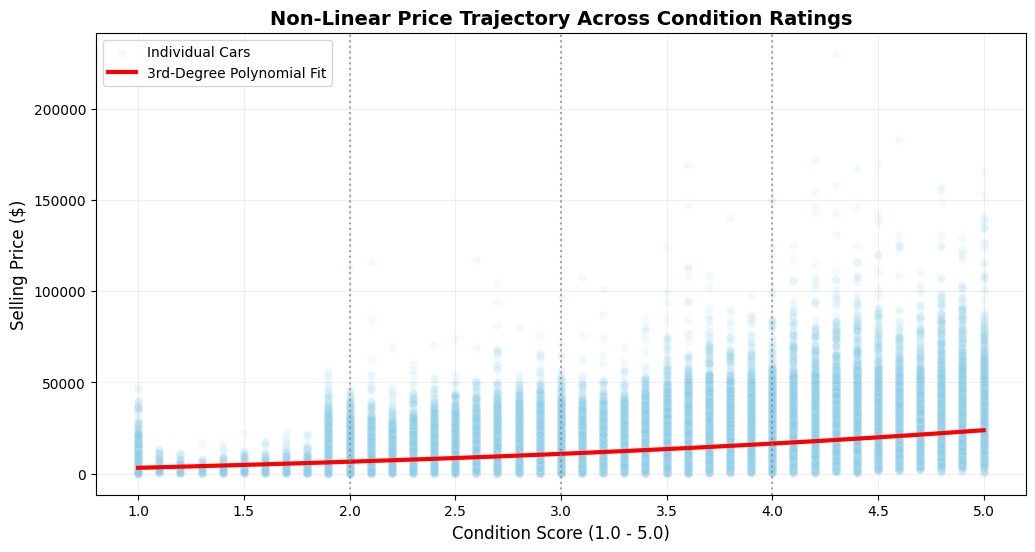

In [41]:
# STEP.2 Identify Non-Linear Condition Rating Thresholds
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# 1. Prepare data from your training set
df_condition = train_df[['condition', 'sellingprice_actual']].dropna().sort_values(by='condition')
X_cond = df_condition[['condition']]
y_cond = df_condition['sellingprice_actual']

# 2. Fit a 3rd-degree polynomial to capture the non-linear curvature/bends
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X_cond)

poly_model = LinearRegression()
poly_model.fit(X_poly, y_cond)

# 3. Create an array of condition scores from 1.0 to 5.0 to plot the smooth curve
x_fit = np.linspace(1.0, 5.0, 100).reshape(-1, 1)
x_fit_poly = poly.transform(x_fit)
y_fit = poly_model.predict(x_fit_poly)

# 4. Plot the results
plt.figure(figsize=(12, 6))

# Scatter plot of raw data points with transparency to see density splits
sns.scatterplot(data=train_df, x='condition', y='sellingprice_actual', 
                alpha=0.1, color='skyblue', label='Individual Cars')

# Overlay the 3rd-Degree Polynomial Trendline
plt.plot(x_fit, y_fit, color='red', linewidth=3, label='3rd-Degree Polynomial Fit')

# Highlight the prominent psychological thresholds visually (e.g., integer scores)
for threshold in [2.0, 3.0, 4.0]:
    plt.axvline(x=threshold, color='gray', linestyle=':', alpha=0.7)

plt.title('Non-Linear Price Trajectory Across Condition Ratings', fontsize=14, fontweight='bold')
plt.xlabel('Condition Score (1.0 - 5.0)', fontsize=12)
plt.ylabel('Selling Price ($)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

--- Mutual Information Predictive Power Scores ---
age                0.426153
odometer           0.396628
mileage_peryear    0.281802
dtype: float64
--------------------------------------------------



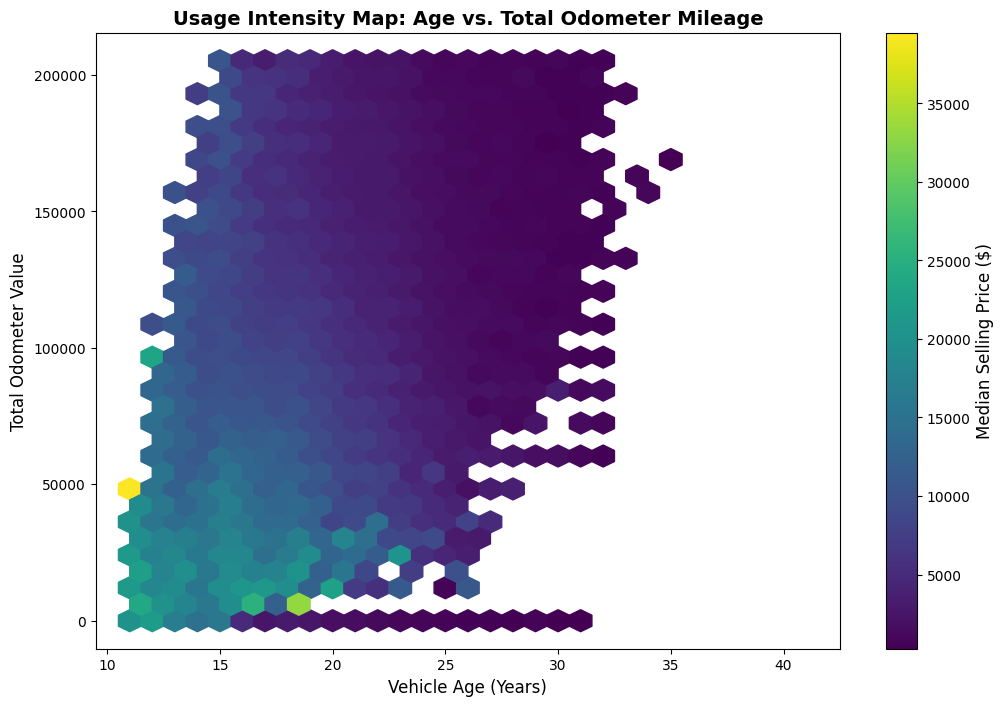

In [42]:
# STEP.3 Evaluate Usage Intensity (mileage_peryear) Effectiveness
from sklearn.feature_selection import mutual_info_regression

# 1. Take a representative sample (e.g., 50,000 rows) to calculate Mutual Information quickly
mi_sample = train_df[['age', 'odometer', 'mileage_peryear', 'sellingprice_actual']].dropna().sample(50000, random_state=42)
X_mi = mi_sample[['age', 'odometer', 'mileage_peryear']]
y_mi = mi_sample['sellingprice_actual']

# 2. Compute Mutual Information Scores
mi_scores = mutual_info_regression(X_mi, y_mi, random_state=42)
mi_results = pd.Series(mi_scores, index=X_mi.columns).sort_values(ascending=False)

print("--- Mutual Information Predictive Power Scores ---")
print(mi_results)
print("--------------------------------------------------\n")

# 3. Hexbin / Joint Contour plot to see pricing across Age vs Odometer density profiles
plt.figure(figsize=(12, 8))
plt.hexbin(train_df['age'], train_df['odometer'], C=train_df['sellingprice_actual'], 
           gridsize=30, cmap='viridis', reduce_C_function=np.median, mincnt=5)
cb = plt.colorbar()
cb.set_label('Median Selling Price ($)', fontsize=12)
plt.title('Usage Intensity Map: Age vs. Total Odometer Mileage', fontsize=14, fontweight='bold')
plt.xlabel('Vehicle Age (Years)', fontsize=12)
plt.ylabel('Total Odometer Value', fontsize=12)
plt.show()

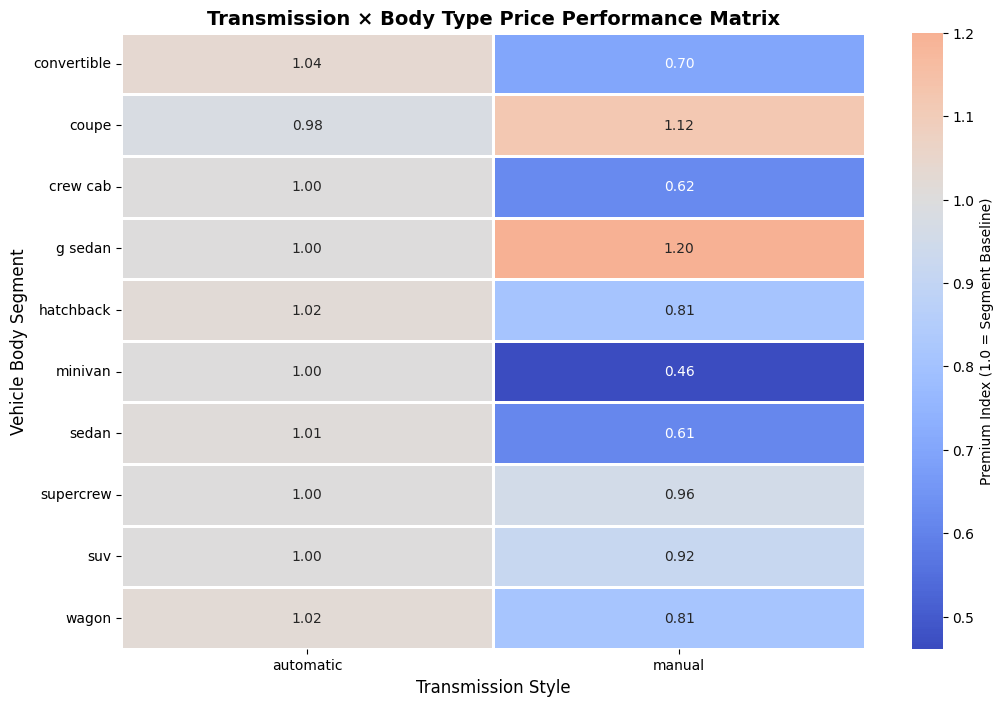

In [43]:
# STEP.4 Uncover High-Performing Transmission × Body Type Combinations
# 1. Ensure uniform formatting for categories
train_df['transmission'] = train_df['transmission'].str.lower().str.strip()
train_df['body'] = train_df['body'].str.lower().str.strip()

# Filter out 'unknown' records to ensure clean insights
df_combinations = train_df[(train_df['body'] != 'unknown') & (train_df['transmission'].isin(['automatic', 'manual']))]
top_bodies = df_combinations['body'].value_counts().nlargest(10).index
df_combinations = df_combinations[df_combinations['body'].isin(top_bodies)]

# 2. Calculate baseline median price for each body segment
body_baselines = df_combinations.groupby('body')['sellingprice_actual'].median()

# 3. Calculate median price for each Body x Transmission pairing
combo_medians = df_combinations.groupby(['body', 'transmission'])['sellingprice_actual'].median().unstack()

# 4. Divide combination medians by the global segment baseline to get the Index Matrix
premium_index_matrix = combo_medians.div(body_baselines, axis=0)

# 5. Visualize findings using a customized diverging Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(premium_index_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=1.0,
            linewidths=1, linecolor='white', cbar_kws={'label': 'Premium Index (1.0 = Segment Baseline)'})
plt.title('Transmission × Body Type Price Performance Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Vehicle Body Segment', fontsize=12)
plt.xlabel('Transmission Style', fontsize=12)
plt.show()

# |Data Encoding 

In [44]:
# Target Encoding -> model, make, trim
# One hot encoding -> Transmission, state, color, interior, body

In [45]:
# Data Encoding
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from category_encoders import TargetEncoder # Ensure category_encoders is installed
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Define feature groups based on your encoding strategy
target_encode_cols = ['make', 'model', 'trim']
one_hot_encode_cols = ['transmission', 'state', 'color', 'interior', 'body']
numerical_cols = ['year', 'age', 'mileage_peryear', 'odometer', 'condition']

# 2. Setup the ColumnTransformer pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('target', TargetEncoder(), target_encode_cols),
        ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'), one_hot_encode_cols)
    ],
    remainder='passthrough' # Keeps numerical columns as they are
)

# 3. Fit the encoder on Training data and transform both sets
preprocessor.fit(X_train, y_train)

# Transform the training partition for model fitting
X_train_encoded = preprocessor.transform(X_train)
X_test_encoded = preprocessor.transform (X_test)

## Baseline Model -> LightBGM

In [46]:
from lightgbm import LGBMRegressor
model = LGBMRegressor(n_estimators = 500, learning_rate = 0.05,random_state = 42)
model.fit(X_train_encoded, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.029326 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1450
[LightGBM] [Info] Number of data points in the train set: 344718, number of used features: 139
[LightGBM] [Info] Start training from score 9.251588


LGBMRegressor(learning_rate=0.05, n_estimators=500, random_state=42)

In [47]:
lgb_preds = model.predict(X_test_encoded)

lgb_mae = mean_absolute_error(np.expm1(y_test),np.expm1(lgb_preds))

lgb_r2 = r2_score(np.expm1(y_test), np.expm1(lgb_preds))
print(f"LightGBM MAE = ${(lgb_mae) : .2f}")
print(f"LightGBM R2 = {lgb_r2 : .2f}")

LightGBM MAE = $ 1544.77
LightGBM R2 =  0.92


## Model Training

In [48]:
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

print("Starting 5-Fold Cross-Validation on baseline model...")

# 1. Define the cross-validation strategy
# We use 5 folds to get a robust estimate without taking too much time
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 2. Compute cross-validation scores using R-squared
# Note: LightGBM will train 5 separate times on different subsets of your data
cv_scores = cross_val_score(model, X_train_encoded, y_train, cv=kf, scoring='r2')

print("\n--- Cross-Validation Results ---")
print(f"Folds R² Scores: {np.round(cv_scores, 4)}")
print(f"Mean CV R² Score: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")
print("--------------------------------")

Starting 5-Fold Cross-Validation on baseline model...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005360 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1441
[LightGBM] [Info] Number of data points in the train set: 275774, number of used features: 134
[LightGBM] [Info] Start training from score 9.251272
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005444 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1442
[LightGBM] [Info] Number of data points in the train set: 275774, number of used features: 135
[LightGBM] [Info] Start training from score 9.252457
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005396 seconds.
You can set `force_row_wis

In [49]:
import warnings

warnings.filterwarnings('ignore', category= UserWarning)
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMRegressor

# 1. Define a targeted parameter grid for LightGBM
param_dist = {
    'n_estimators': [300, 500, 700],
    'learning_rate': [0.03, 0.05, 0.1],
    'num_leaves': [31, 50, 70],
    'max_depth': [-1, 10, 15],
    'subsample': [0.8, 1.0]
}

# 2. Initialize a new base model
lgbm_tune = LGBMRegressor(random_state=42, verbose=-1)

# 3. Setup Randomized Search
# n_iter=5 means it will randomly pick and try 5 combinations across 3 folds
random_search = RandomizedSearchCV(
    estimator=lgbm_tune,
    param_distributions=param_dist,
    n_iter=5, 
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

print("Searching for the best hyperparameters (this may take a few minutes)...")
random_search.fit(X_train_encoded, y_train)

print("\nBest Parameters Found:")
print(random_search.best_params_)
print(f" Best Search R² Score: {random_search.best_score_ : .4f} ")

Searching for the best hyperparameters (this may take a few minutes)...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v


Best Parameters Found:
{'subsample': 0.8, 'num_leaves': 50, 'n_estimators': 700, 'max_depth': 15, 'learning_rate': 0.1}
 Best Search R² Score:  0.9431 


## Evaluation


=== FINAL TUNED MODEL METRICS ===
Final Mean Absolute Error (MAE): $1242.85
Final Root Mean Squared Error (RMSE): $2246.55
Final R² Score: 0.9460



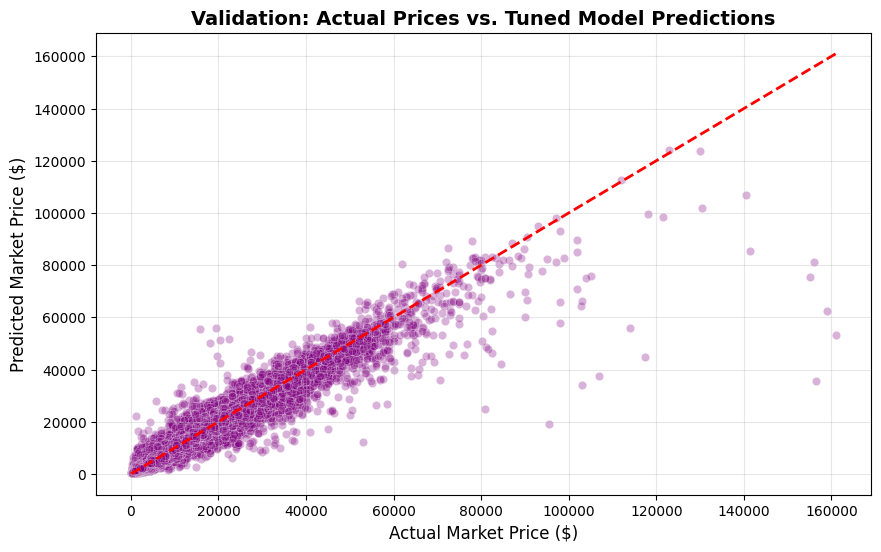

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Extract the best tuned model
best_model = random_search.best_estimator_

# 2. Predict on Test Set (Outputs are log prices)
tuned_log_preds = best_model.predict(X_test_encoded)

# 3. Convert back to actual dollar amounts using np.expm1
final_predictions = np.expm1(tuned_log_preds)
actual_prices = np.expm1(y_test)

# 4. Calculate final metrics
final_mae = mean_absolute_error(actual_prices, final_predictions)
final_rmse = np.sqrt(mean_squared_error(actual_prices, final_predictions))
final_r2 = r2_score(actual_prices, final_predictions)

print("\n=== FINAL TUNED MODEL METRICS ===")
print(f"Final Mean Absolute Error (MAE): ${final_mae:.2f}")
print(f"Final Root Mean Squared Error (RMSE): ${final_rmse:.2f}")
print(f"Final R² Score: {final_r2:.4f}")
print("=================================\n")

# 5. Visual Validation Plot: Actual vs. Predicted
plt.figure(figsize=(10, 6))
sns.scatterplot(x=actual_prices, y=final_predictions, alpha=0.3, color='purple')
plt.plot([actual_prices.min(), actual_prices.max()], [actual_prices.min(), actual_prices.max()], 'r--', lw=2)
plt.title('Validation: Actual Prices vs. Tuned Model Predictions', fontsize=14, fontweight='bold')
plt.xlabel('Actual Market Price ($)', fontsize=12)
plt.ylabel('Predicted Market Price ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()